<a href="https://colab.research.google.com/github/yakaHan/Tugas/blob/main/Final%20Project%20Big%20Data%20Fundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/Amazon Sale Report.csv')

<ipython-input-3-1570349549>:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Amazon Sale Report.csv')


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

Preprocessing Data

In [5]:
import pandas as pd
import numpy as np

# Handle missing values
df['Courier Status'].fillna('Unknown', inplace=True)
df['currency'].fillna(df['currency'].mode()[0], inplace=True)
df['Amount'].fillna(0, inplace=True)  # atau mean/median jika lebih sesuai
df[['ship-city', 'ship-state', 'ship-postal-code', 'ship-country']] = df[['ship-city', 'ship-state', 'ship-postal-code', 'ship-country']].fillna('Unknown')
df['promotion-ids'].fillna('No Promotion', inplace=True)
df['fulfilled-by'].fillna('Unknown', inplace=True)

# Drop kolom yang tidak diperlukan
df.drop(['Unnamed: 22', 'index'], axis=1, inplace=True, errors='ignore')

# Konversi tipe data
df['Date'] = pd.to_datetime(df['Date'])
df['ship-postal-code'] = df['ship-postal-code'].astype(str)

<ipython-input-5-1021487384>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier Status'].fillna('Unknown', inplace=True)
<ipython-input-5-1021487384>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

Feeturing Engineering

In [6]:
# Ekstrak informasi tanggal
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekdayName'] = df['Date'].dt.day_name()

# Kategorisasi amount
df['Amount_Category'] = pd.cut(df['Amount'],
                              bins=[0, 20, 50, 100, 200, 500, np.inf],
                              labels=['<20', '20-50', '50-100', '100-200', '200-500', '500+'])

# Flag untuk pesanan dengan promo
df['Has_Promo'] = df['promotion-ids'] != 'No Promotion'

Analisis EDA

In [10]:
print(df.describe())
print(df['Status'].value_counts())
print(df['Category'].value_counts())
print(df['Sales Channel '].value_counts())

                                Date            Qty         Amount      Year  \
count                         128975  128975.000000  128975.000000  128975.0   
mean   2022-05-12 11:49:27.951928576       0.904431     609.363662    2022.0   
min              2022-03-31 00:00:00       0.000000       0.000000    2022.0   
25%              2022-04-20 00:00:00       1.000000     413.000000    2022.0   
50%              2022-05-10 00:00:00       1.000000     583.000000    2022.0   
75%              2022-06-04 00:00:00       1.000000     771.000000    2022.0   
max              2022-06-29 00:00:00      15.000000    5584.000000    2022.0   
std                              NaN       0.313354     313.347147       0.0   

               Month            Day      DayOfWeek  
count  128975.000000  128975.000000  128975.000000  
mean        4.909192      14.925978       3.012088  
min         3.000000       1.000000       0.000000  
25%         4.000000       7.000000       1.000000  
50%         5.

Analisis Tren Waktu

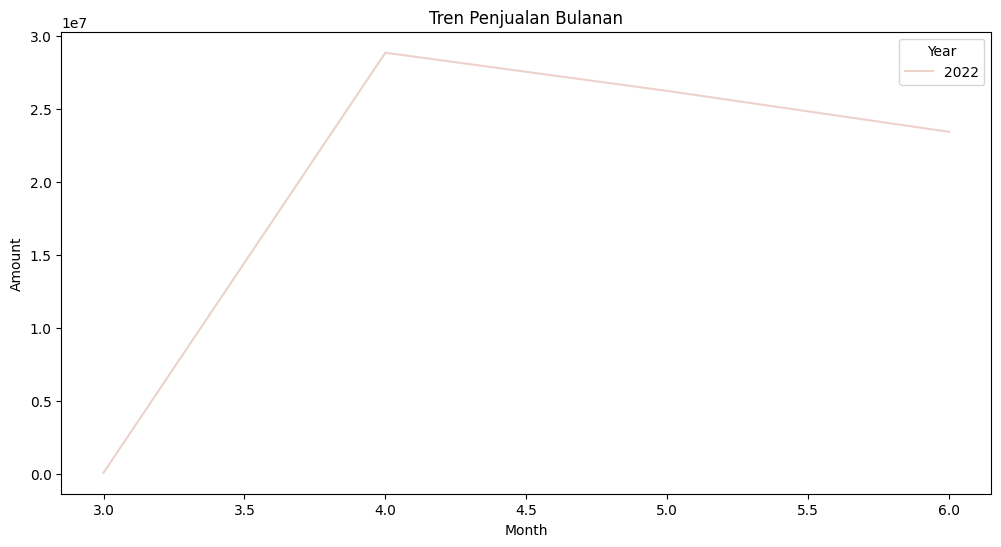

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tren penjualan bulanan
monthly_sales = df.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Amount', hue='Year')
plt.title('Tren Penjualan Bulanan')
plt.show()

Analisis Produk

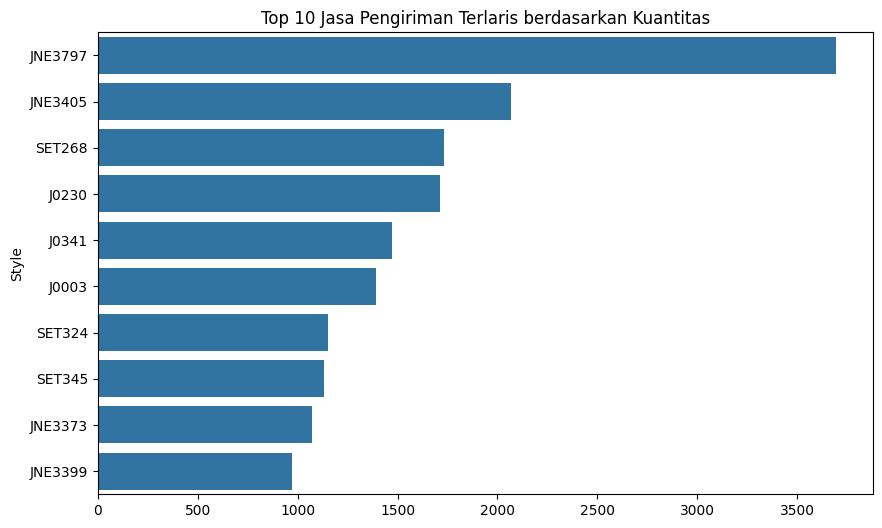

In [13]:
# Top 10 produk terlaris
top_products = df.groupby('Style')['Qty'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Jasa Pengiriman Terlaris berdasarkan Kuantitas')
plt.show()

Analisis Geografis

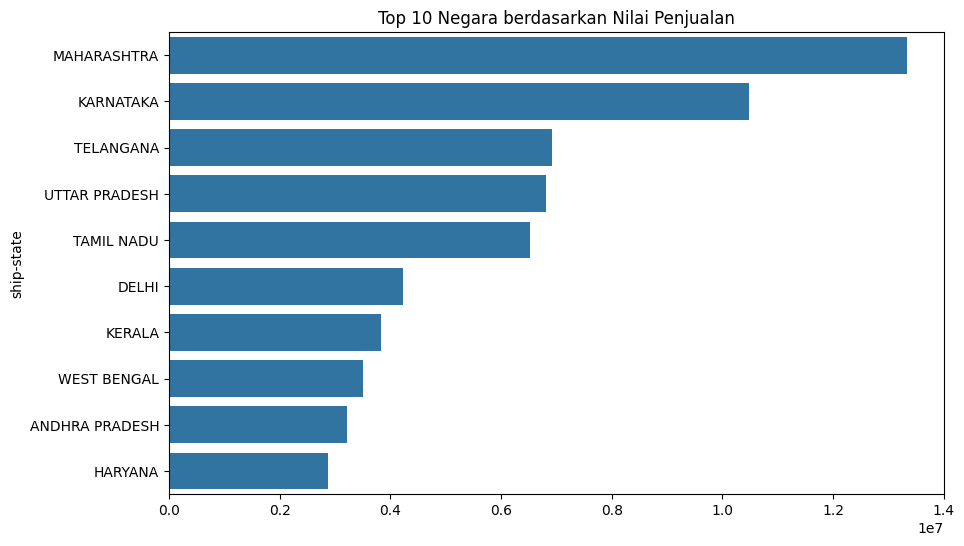

In [15]:
# Penjualan berdasarkan negara
sales_by_country = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=sales_by_country.values, y=sales_by_country.index)
plt.title('Top 10 Kota berdasarkan Nilai Penjualan')
plt.show()

In [17]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# Load dataset
@st.cache_data
def load_data():
    # Ganti 'your_dataset.csv' dengan nama file Anda
    df = pd.read_csv('Amazon Sale Report.csv')

    # Bersihkan dan konversi kolom Date
    # Handle kasus seperti "04-30-22 00:00-22" -> ambil bagian tanggalnya saja
    df['Date'] = df['Date'].str.split(' ').str[0]

    # Konversi ke datetime dan ekstrak tahun
    df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')
    df['Year'] = df['Date'].dt.year

    return df

df = load_data()

# Sidebar untuk filter
st.sidebar.header('Filter Data')

# 1. Filter Tahun (otomatis 2022 saja berdasarkan contoh data)
selected_year = st.sidebar.selectbox(
    'Tahun',
    options=sorted(df['Year'].unique()),
    index=0  # Default pilih tahun pertama
)

# 2. Filter Kategori Produk
available_categories = ['Semua'] + sorted(df['Category'].dropna().unique().tolist())
selected_category = st.sidebar.multiselect(
    'Kategori Produk',
    options=available_categories,
    default=['Semua']
)

# Filter data berdasarkan pilihan
filtered_df = df[df['Year'] == selected_year]

if 'Semua' not in selected_category:
    filtered_df = filtered_df[filtered_df['Category'].isin(selected_category)]

# Main dashboard
st.title('Dashboard Analisis E-Commerce')

# Menampilkan metrik utama
col1, col2, col3 = st.columns(3)
col1.metric("Total Penjualan", f"${filtered_df['Amount'].sum():,.2f}")
col2.metric("Total Order", filtered_df.shape[0])
col3.metric("Rata-rata Nilai Order", f"${filtered_df['Amount'].mean():,.2f}")

# Tren bulanan
st.subheader('Tren Penjualan Bulanan')
monthly_sales = filtered_df.groupby(filtered_df['Date'].dt.month)['Amount'].sum()
st.bar_chart(monthly_sales)

# Top 5 produk terlaris
st.subheader('Top 5 Produk Terlaris')
top_products = filtered_df.groupby('Style')['Qty'].sum().nlargest(5)
st.bar_chart(top_products)

# Data tabel
st.subheader('Data Transaksi')
st.dataframe(filtered_df.head(10))


ModuleNotFoundError: No module named 'streamlit'